## Workshop-1 Sturdy-Octo-Disco-Adding-Sunglasses-for-a-Cool-New-Look
### NAME: EZHIL NEVEDHA K
### REG NO: 212223230055
### SLOT NO: T2-K11

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [32]:
faceImage = cv2.imread(r"C:\Users\admin\Pictures\Screenshots\Screenshot 2026-05-01 150311.png")

In [33]:
glassPNG=cv2.imread(r"C:\Users\admin\Pictures\Screenshots\Screenshot 2026-05-01 144859.png")

In [34]:
faceImage_rgb = cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB)

In [35]:
glassBGR = glassPNG[:, :, :3]

In [36]:
grayGlass = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)

In [38]:
_, glassMask1 = cv2.threshold(grayGlass, 240, 255, cv2.THRESH_BINARY_INV)
glassMask = cv2.merge((glassMask1, glassMask1, glassMask1))
glassMask = glassMask / 255.0

In [74]:
faceWithGlasses = faceImage.copy()
h_img, w_img = faceImage.shape[:2]
glass_height = 40
y1 = int(0.30 * h_img)
y2 = y1 + glass_height
aspect_ratio = glassBGR.shape[1] / glassBGR.shape[0]
glass_width = int(glass_height * aspect_ratio*1.5)

In [75]:
x_center = w_img // 2
x1 = x_center - glass_width // 2
x2 = x_center + glass_width // 2

In [76]:
glass_resized = cv2.resize(glassBGR, (x2-x1, y2-y1))
glassMask_resized = cv2.resize(glassMask, (x2-x1, y2-y1))

In [77]:
eyeROI = faceWithGlasses[y1:y2, x1:x2]

In [78]:
maskedEye = cv2.multiply(eyeROI.astype(float), (1 - glassMask_resized))
maskedGlass = cv2.multiply(glass_resized.astype(float), glassMask_resized)

In [79]:
eyeFinal = cv2.add(maskedEye, maskedGlass)
eyeFinal = np.uint8(eyeFinal)


In [80]:
faceWithGlasses[y1:y2, x1:x2] = eyeFinal

(-0.5, 258.5, 263.5, -0.5)

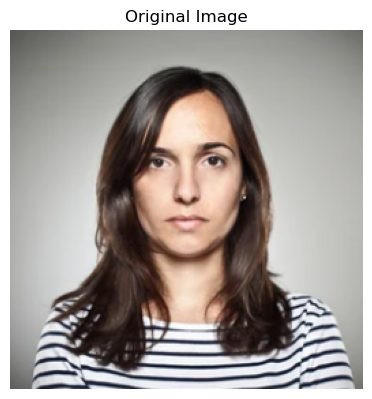

In [81]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(faceImage_rgb)
plt.title("Original Image")
plt.axis('off')

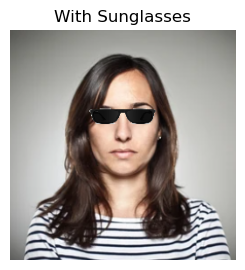

In [82]:
plt.subplot(1,2,2)
plt.imshow(faceWithGlasses[:,:,::-1])
plt.title("With Sunglasses")
plt.axis('off')
plt.show()